# Mini-Challenge 2 — Visualise the loss-makers
### Saint Mary's · Friday morning, 11:25

> *"In a chart she can read in 5 seconds: the top 10 loss-making DRGs at Saint Mary's. Title, axis labels, the works."*

**Time:** 25 min · **Mode:** tandem · **Goal:** build one publication-ready bar chart.

---

# Solution — Mini-Challenge 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
DATA = next((p / "data" for p in [HERE, *HERE.parents] if (p / "data").exists()), None)
assert DATA is not None, "data/ folder not found"

enc = pd.read_csv(DATA / "encounters.csv", parse_dates=["admission_date","discharge_date"])
drg = pd.read_csv(DATA / "drg_catalog.csv")
patients = pd.read_csv(DATA / "patients.csv")

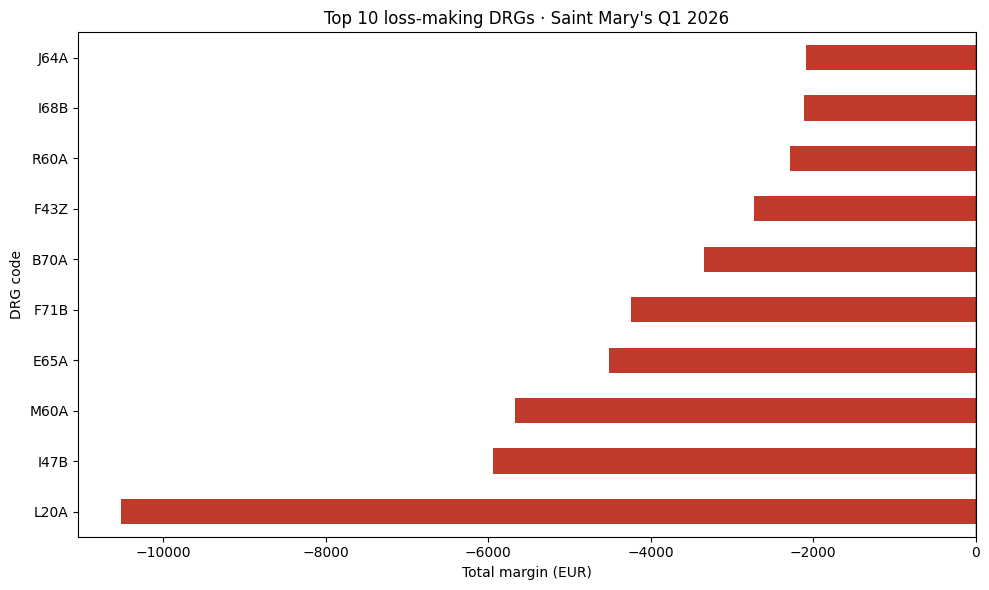

In [2]:
enc = enc.merge(drg, on="drg_code", how="left")
enc["margin_eur"] = enc["base_reimbursement_eur"] - enc["actual_cost_eur"]
top_loss = enc.groupby("drg_code")["margin_eur"].sum().sort_values().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_loss.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Top 10 loss-making DRGs · Saint Mary's Q1 2026")
ax.set_xlabel("Total margin (EUR)")
ax.set_ylabel("DRG code")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

## Fast-Track

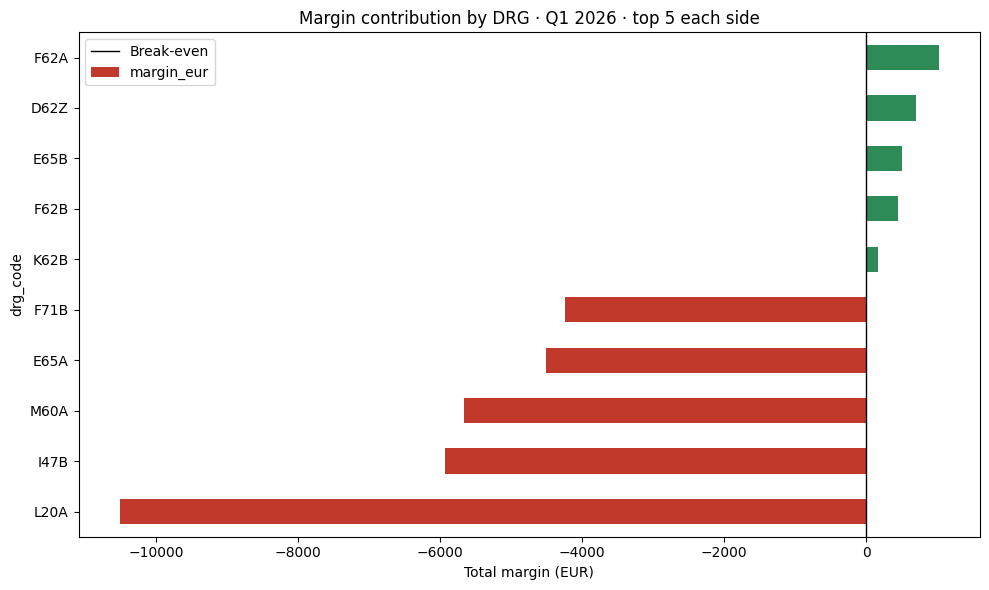

In [3]:
margin_by_drg = enc.groupby("drg_code")["margin_eur"].sum().sort_values()
combined = pd.concat([margin_by_drg.head(5), margin_by_drg.tail(5)]).sort_values()
colors = ["#c0392b" if v < 0 else "#2e8b57" for v in combined.values]

fig, ax = plt.subplots(figsize=(10, 6))
combined.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Margin contribution by DRG · Q1 2026 · top 5 each side")
ax.set_xlabel("Total margin (EUR)")
ax.axvline(0, color="black", linewidth=1, label="Break-even")
ax.legend()
plt.tight_layout()
plt.show()